# 02 — Exploratory Data Analysis

Produces Figures 1, 2, and 3 of the Interim Report:
- **Figure 1.** Stage-1 activity map (process-mining diagram).
- **Figure 2.** Distribution of Stage-1 case processing times.
- **Figure 3.** Stage-1 monthly KPIs across the 19-month panel (visual support for the RQ3 ITS).

All output PNGs are written to `figures/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

ROOT = Path('..').resolve()
PROC = ROOT / 'data' / 'processed'
FIG  = ROOT / 'figures'; FIG.mkdir(exist_ok=True)

case = pd.read_csv(PROC / 'case_level_balanced_1000.csv')
panel = pd.read_csv(PROC / 'stage_month_panel.csv')
print(f'cases: {len(case)}, panel rows: {len(panel)}')

cases: 1000, panel rows: 76


## Figure 1 — Stage-1 activity map

Produced by process discovery on the event log. Activities along the main path; rework loop in orange; AI/ML decision point overlaid in yellow at the end of `A_Complete`.

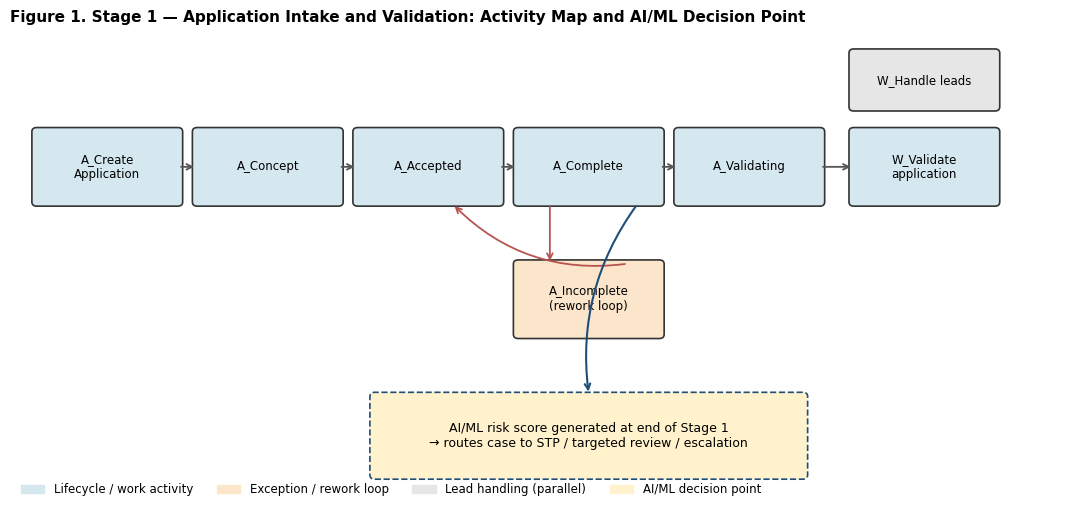

saved fig1_stage1_process_map.png


In [2]:
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,
  'axes.spines.top':False,'axes.spines.right':False,'axes.grid':False})

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.set_xlim(0, 11); ax.set_ylim(0, 5.5); ax.axis('off')
ax.set_title('Figure 1. Stage 1 — Application Intake and Validation: '
             'Activity Map and AI/ML Decision Point',
             loc='left', pad=15, fontsize=11, fontweight='bold')

def boxes(x, y, w, h, label, fc, ec='#333', ls='-', fs=8.5):
    ax.add_patch(FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle='round,pad=0.05', linewidth=1.2,
        edgecolor=ec, facecolor=fc, linestyle=ls))
    ax.text(x, y, label, ha='center', va='center', fontsize=fs)

main = [(1.0,'A_Create\nApplication'),(2.65,'A_Concept'),(4.3,'A_Accepted'),
        (5.95,'A_Complete'),(7.6,'A_Validating'),(9.4,'W_Validate\napplication')]
for x,lbl in main: boxes(x, 4.0, 1.45, 0.85, lbl, '#D5E8F0')
boxes(9.4, 5.05, 1.45, 0.65, 'W_Handle leads', '#E6E6E6')
boxes(5.95, 2.4, 1.45, 0.85, 'A_Incomplete\n(rework loop)', '#FCE6CB')
boxes(5.95, 0.75, 4.4, 0.95,
      'AI/ML risk score generated at end of Stage 1\n'
      '→ routes case to STP / targeted review / escalation',
      '#FFF2CC', ec='#1F4E79', ls='--', fs=9)

xs = [m[0] for m in main]
for i in range(len(xs)-1):
    ax.annotate('', xy=(xs[i+1]-0.73,4.0), xytext=(xs[i]+0.73,4.0),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.3))
ax.annotate('', xy=(5.55, 2.83), xytext=(5.55, 3.55),
    arrowprops=dict(arrowstyle='->', color='#B85450', lw=1.3))
ax.annotate('', xy=(4.55, 3.55), xytext=(6.35, 2.83),
    arrowprops=dict(arrowstyle='->', color='#B85450', lw=1.3,
                    connectionstyle='arc3,rad=-0.25'))
ax.annotate('', xy=(5.95, 1.25), xytext=(6.45, 3.55),
    arrowprops=dict(arrowstyle='->', color='#1F4E79', lw=1.5,
                    connectionstyle='arc3,rad=0.20'))

ax.legend(handles=[
    mpatches.Patch(color='#D5E8F0', label='Lifecycle / work activity'),
    mpatches.Patch(color='#FCE6CB', label='Exception / rework loop'),
    mpatches.Patch(color='#E6E6E6', label='Lead handling (parallel)'),
    mpatches.Patch(color='#FFF2CC', label='AI/ML decision point'),
], loc='lower left', bbox_to_anchor=(0.0,-0.02),
fontsize=8.5, frameon=False, ncol=4)
plt.tight_layout()
plt.savefig(FIG / 'fig1_stage1_process_map.png', dpi=160,
            bbox_inches='tight'); plt.show()
print('saved fig1_stage1_process_map.png')

## Figure 2 — distribution of Stage-1 processing times

Right-skewed; the pooled P75 defines the operational SLA threshold.

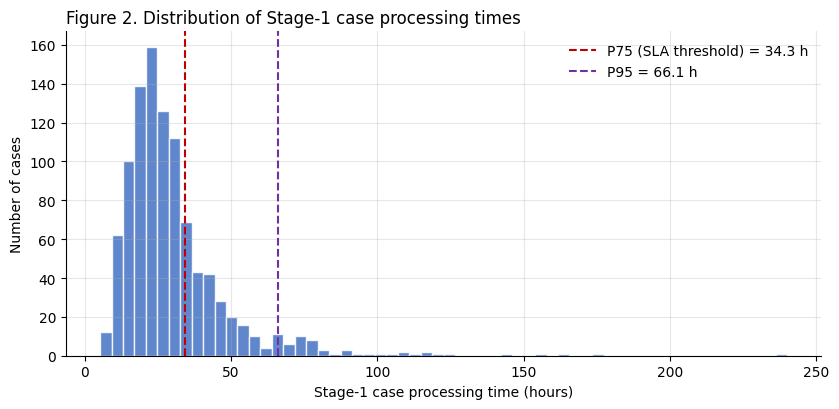

P75 = 34.31 h, P95 = 66.12 h, mean = 30.35 h


In [3]:
tat = case['stage1_processing_time'].values
p75 = np.percentile(tat, 75); p95 = np.percentile(tat, 95)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(tat, bins=60, color='#4472C4', edgecolor='white', alpha=0.85)
ax.axvline(p75, color='#C00000', ls='--', lw=1.5,
    label=f'P75 (SLA threshold) = {p75:.1f} h')
ax.axvline(p95, color='#7030A0', ls='--', lw=1.5,
    label=f'P95 = {p95:.1f} h')
ax.set_xlabel('Stage-1 case processing time (hours)')
ax.set_ylabel('Number of cases')
ax.set_title('Figure 2. Distribution of Stage-1 case processing times',
    loc='left'); ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG / 'fig2_processing_time_hist.png',
    dpi=160, bbox_inches='tight'); plt.show()
print(f'P75 = {p75:.2f} h, P95 = {p95:.2f} h, mean = {tat.mean():.2f} h')

## Figure 3 — Stage-1 monthly KPIs across the 19-month panel

Panel (a): mean turnaround time. Panel (b): exception rate. Dotted line marks the system change at t* = 7 (first BPIC17 month).

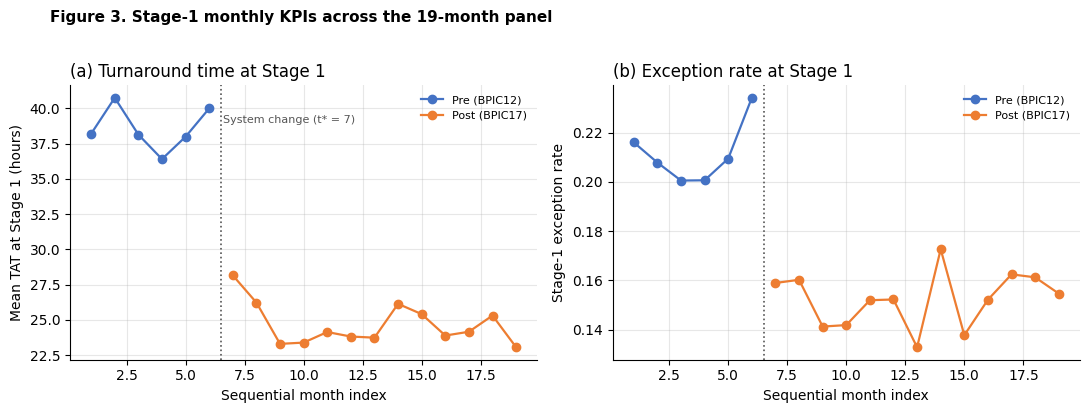

In [4]:
s1 = panel[panel.stage_id == 'S1'].sort_values('month_index')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, ylabel, title in [
    (axes[0], 'mean_processing_time', 'Mean TAT at Stage 1 (hours)',
     '(a) Turnaround time at Stage 1'),
    (axes[1], 'exception_rate', 'Stage-1 exception rate',
     '(b) Exception rate at Stage 1')]:
    pre  = s1[s1.era == 0]; post = s1[s1.era == 1]
    ax.plot(pre.month_index, pre[col], 'o-', color='#4472C4', lw=1.6,
            label='Pre (BPIC12)')
    ax.plot(post.month_index, post[col], 'o-', color='#ED7D31', lw=1.6,
            label='Post (BPIC17)')
    ax.axvline(6.5, color='#555', ls=':', lw=1.2)
    ax.set_xlabel('Sequential month index'); ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left')
    ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.3)
axes[0].text(6.6, axes[0].get_ylim()[1]*0.95, 'System change (t* = 7)',
    fontsize=8, color='#555', ha='left', va='top')
fig.suptitle('Figure 3. Stage-1 monthly KPIs across the 19-month panel',
    x=0.05, y=1.02, ha='left', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig(FIG / 'fig3_its_panel.png', dpi=160,
    bbox_inches='tight'); plt.show()

## EDA insight summary
Three EDA findings carry forward into modelling:
1. The Stage-1 activity flow contains a documented rework loop — the natural insertion point for the AI/ML decision is the end of A_Complete.
2. Stage-1 processing time is strongly right-skewed; a binary SLA-breach flag at P75 is the operationally meaningful summary.
3. Both KPIs show a visible level shift at t* = 7, supporting the ITS specification used in notebook 05.